<a href="https://colab.research.google.com/github/LipeSilva83/modelos-de-regress-o-linear/blob/main/analise_modelos_regressao_portfolio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise de Modelos de Regressão Linear (Portfólio)

Este notebook carrega o dataset `Precos_de_casas.csv` (ou `Preços_de_casas.csv`) e realiza: EDA, limpeza, split treino/teste, treinamento de um modelo linear, avaliação (RMSE, MAE, R²), summary OLS para interpretação estatística e visualizações.

Objetivo: produzir um notebook limpo e reproduzível adequado para inclusão em um portfólio profissional.

In [1]:
# Imports e configurações
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import statsmodels.api as sm

sns.set_style('whitegrid')
%matplotlib inline

### Download do Dataset via GitHub
Substitua a URL abaixo pela URL 'Raw' do seu arquivo no GitHub para que o notebook possa baixá-lo automaticamente.

In [9]:
url_github = "https://github.com/LipeSilva83/modelos-de-regress-o-linear/blob/main/Arquivos/Precos_de_casas.csv"

import os

if os.path.exists('Precos_de_casas.csv') and os.path.getsize('Precos_de_casas.csv') == 0:
    os.remove('Precos_de_casas.csv')

if not os.path.exists('Precos_de_casas.csv'):
    print(f"Baixando dados de: {url_github}")
    os.system(f"wget {url_github} -O Precos_de_casas.csv")

if os.path.exists('Precos_de_casas.csv') and os.path.getsize('Precos_de_casas.csv') > 0:
    print("Sucesso: Arquivo baixado e pronto para uso!")
else:
    print("ERRO: O arquivo ainda está vazio. Verifique a URL do GitHub.")

Sucesso: Arquivo baixado e pronto para uso!


## 1) Detectar/renomear arquivo de dados (se necessário)


In [10]:
import pandas as pd
import os

csv_path = 'Precos_de_casas.csv'

if os.path.exists(csv_path) and os.path.getsize(csv_path) > 0:
    # O dataset de exemplo usa vírgula como separador
    df = pd.read_csv(csv_path)
    print(f'Dataset carregado com sucesso! Formato: {df.shape}')
    print(df.head())
else:
    print('Erro: Arquivo não encontrado ou vazio. Por favor, execute a célula de download acima.')

Dataset carregado com sucesso! Formato: (20640, 10)
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


Nesta etapa, o arquivo CSV é carregado em um DataFrame do Pandas. Realizamos uma verificação inicial para garantir que o arquivo não esteja vazio e exibimos as primeiras linhas (`head`) para validar se as colunas e os dados foram importados corretamente antes de iniciar a análise.

## 2) EDA inicial e verificação dos dados

In [11]:
# Visão geral
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


Nesta etapa, utilizamos o comando `df.head()` para visualizar as primeiras 5 linhas do conjunto de dados. Isso nos permite verificar rapidamente se o carregamento foi feito corretamente, conferindo os nomes das colunas e os formatos dos valores iniciais.

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [13]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
longitude,20640.0,NaN,NaN,NaN,-119.569704,2.003532,-124.35,-121.8,-118.49,-118.01,-114.31
latitude,20640.0,NaN,NaN,NaN,35.631861,2.135952,32.54,33.93,34.26,37.71,41.95
housing_median_age,20640.0,NaN,NaN,NaN,28.639486,12.585558,1.0,18.0,29.0,37.0,52.0
total_rooms,20640.0,NaN,NaN,NaN,2635.763081,2181.615252,2.0,1447.75,2127.0,3148.0,39320.0
total_bedrooms,20433.0,NaN,NaN,NaN,537.870553,421.38507,1.0,296.0,435.0,647.0,6445.0
population,20640.0,NaN,NaN,NaN,1425.476744,1132.462122,3.0,787.0,1166.0,1725.0,35682.0
households,20640.0,NaN,NaN,NaN,499.53968,382.329753,1.0,280.0,409.0,605.0,6082.0
median_income,20640.0,NaN,NaN,NaN,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,NaN,NaN,NaN,206855.816909,115395.615874,14999.0,119600.0,179700.0,264725.0,500001.0
ocean_proximity,20640,5,<1H OCEAN,9136,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Nesta célula, utilizamos o método `df.describe(include='all').T` para gerar um resumo estatístico completo do DataFrame. O sufixo `.T` (transposição) facilita a leitura, transformando as colunas originais em linhas, permitindo observar rapidamente a contagem de valores, médias, desvios padrão, valores mínimos/máximos e quartis de cada variável.

In [17]:
print('Missing por coluna:\n', df.isna().sum())
print('Linhas duplicadas:', df.duplicated().sum())

Missing por coluna:
 longitude                     0
latitude                      0
housing_median_age            0
total_rooms                   0
total_bedrooms                0
population                    0
households                    0
median_income                 0
median_house_value            0
ocean_proximity_INLAND        0
ocean_proximity_ISLAND        0
ocean_proximity_NEAR BAY      0
ocean_proximity_NEAR OCEAN    0
dtype: int64
Linhas duplicadas: 0


Nesta etapa, realizamos uma verificação de integridade dos dados. O comando `df.isna().sum()` identifica se existem valores ausentes em cada coluna, enquanto `df.duplicated().sum()` checa se há registros repetidos, garantindo que a base de dados esteja limpa antes do processamento.

## 3) Limpeza e pré-processamento rápido
- Renomear colunas para conveniência (remover espaços/acentos)
- Remover linhas sem target
- Dummify variáveis categóricas

In [18]:
# Normalizar nomes de colunas
def normalize_col(c):
    return c.strip().replace(' ', '_').replace('ç','c').replace('ã','a').replace('é','e').replace('ó','o').replace('í','i')

df = df.rename(columns=lambda c: normalize_col(str(c)))

# Identificar coluna alvo: busca por 'preco' ou 'house_value' (do dataset do Colab/GitHub)
target_candidates = [c for c in df.columns if any(x in c.lower() for x in ['preco', 'house_value', 'value'])]

if len(target_candidates) == 0:
    raise ValueError('Não encontrei coluna alvo. Colunas disponíveis: ' + ','.join(df.columns))

ycol = target_candidates[0]
print(f'Coluna alvo identificada: {ycol}')

# Limpeza básica: remover nulos na coluna alvo e tratar NaNs nas outras
df = df.dropna(subset=[ycol])
df = df.fillna(df.median(numeric_only=True))

# Remover IDs
for candidate in ['id', 'index']:
    if candidate in df.columns.str.lower():
        cols_to_drop = [c for c in df.columns if c.lower() == candidate]
        df = df.drop(columns=cols_to_drop)

# Dummify variáveis categóricas (como 'ocean_proximity')
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
if cat_cols:
    df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print(f'Processamento concluído. Novas dimensões: {df.shape}')

Coluna alvo identificada: median_house_value
Processamento concluído. Novas dimensões: (20640, 13)


Nesta etapa de pré-processamento, realizamos a limpeza e organização dos dados: normalizamos os nomes das colunas para evitar erros de sintaxe, identificamos automaticamente a coluna alvo, tratamos valores ausentes preenchendo-os com a mediana e transformamos variáveis categóricas em variáveis numéricas (dummificação) para que possam ser utilizadas pelos modelos de regressão.

## 4) Split treino / teste

In [19]:
X = df.drop(columns=[ycol])
y = df[ycol].astype(float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Treino:', X_train.shape, 'Teste:', X_test.shape)

Treino: (16512, 12) Teste: (4128, 12)


Nesta etapa, dividimos o conjunto de dados em dois grupos: **treino** e **teste**. Utilizamos 80% dos dados para treinar o modelo e reservamos 20% para avaliar sua performance em dados inéditos, garantindo que as métricas de erro reflitam a capacidade de generalização do modelo.

## 5) Treinar LinearRegression (scikit-learn) e avaliar

In [21]:
from sklearn.metrics import root_mean_squared_error

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
# Em versões novas do sklearn, usamos root_mean_squared_error em vez de squared=False
rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'LinearRegression - RMSE: {rmse:.2f}, MAE: {mae:.2f}, R2: {r2:.4f}')

LinearRegression - RMSE: 70060.52, MAE: 50670.74, R2: 0.6254


Nesta etapa, treinamos o modelo de **Regressão Linear** utilizando o Scikit-Learn. Após o ajuste com os dados de treino, realizamos predições no conjunto de teste e calculamos métricas fundamentais como o **RMSE** (Erro Quadrático Médio da Raiz), o **MAE** (Erro Médio Absoluto) e o **R²** (Coeficiente de Determinação), que nos ajuda a entender quão bem o modelo explica a variabilidade dos preços das casas.

## 6) Summary OLS (statsmodels) — interpretação estatística
Observação: OLS dá mais informações sobre significância dos coeficientes e intervalos de confiança. Aqui usamos todas as features (pode ser pesado).

In [23]:
# Converter X para float para garantir que colunas booleanas/objetos sejam tratadas como números
X_numeric = X.astype(float)

# Adicionar constante para o intercepto
X_const = sm.add_constant(X_numeric)

# Ajustar o modelo OLS
model_ols = sm.OLS(y, X_const).fit()
print(model_ols.summary())

                            OLS Regression Results                            
Dep. Variable:     median_house_value   R-squared:                       0.645
Model:                            OLS   Adj. R-squared:                  0.645
Method:                 Least Squares   F-statistic:                     3129.
Date:                Mon, 24 Aug 2026   Prob (F-statistic):               0.00
Time:                        00:10:34   Log-Likelihood:            -2.5917e+05
No. Observations:               20640   AIC:                         5.184e+05
Df Residuals:                   20627   BIC:                         5.185e+05
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

Nesta etapa, utilizamos a biblioteca **statsmodels** para realizar uma regressão via **OLS (Ordinary Least Squares)**. Diferente da implementação do Scikit-Learn, o OLS nos fornece um relatório estatístico completo (summary), permitindo analisar a significância de cada variável através dos valores-p (P>|t|), identificar possíveis problemas de multicolinearidade e observar os intervalos de confiança para os coeficientes do modelo.

## 7) Visualizações: Predito vs Real e Resíduos

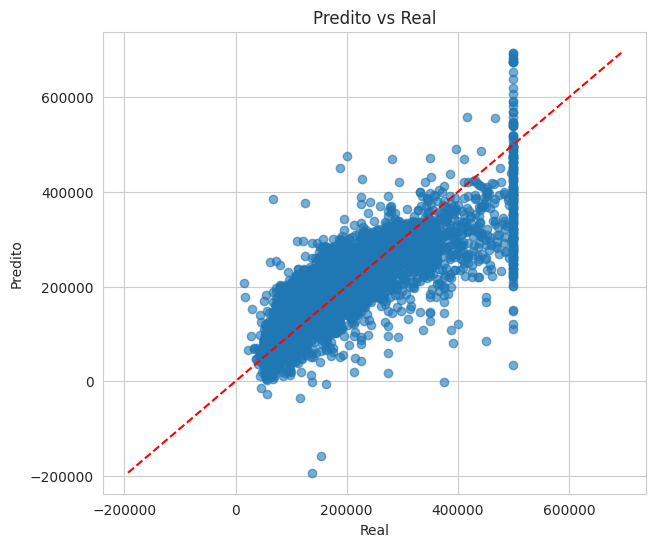

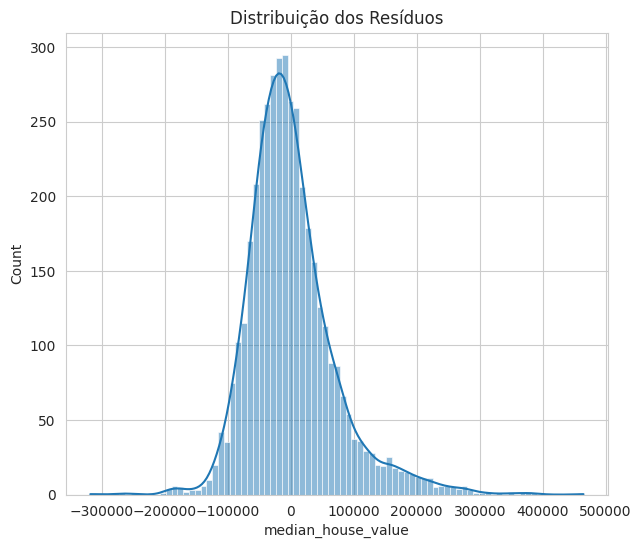

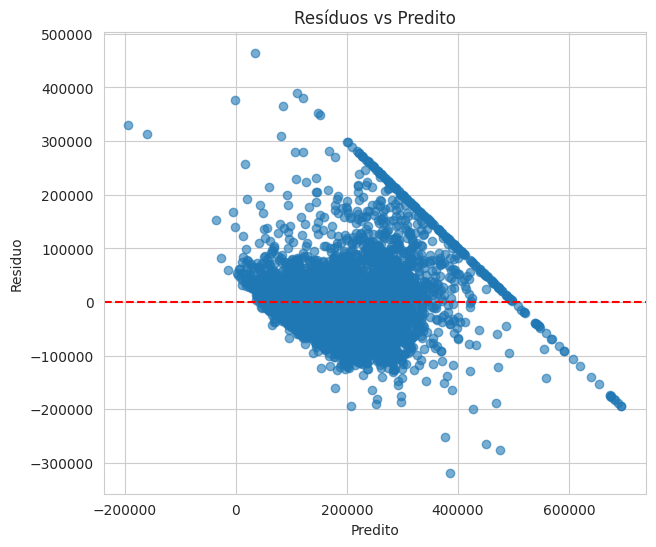

In [24]:
# Predito x Real
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred, alpha=0.6)
mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
plt.plot([mn, mx], [mn, mx], 'r--')
plt.xlabel('Real')
plt.ylabel('Predito')
plt.title('Predito vs Real')
plt.show()

# Resíduos
residuals = y_test - y_pred
plt.figure(figsize=(7,6))
sns.histplot(residuals, kde=True)
plt.title('Distribuição dos Resíduos')
plt.show()

plt.figure(figsize=(7,6))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('Predito')
plt.ylabel('Residuo')
plt.title('Resíduos vs Predito')
plt.show()

Nesta etapa final de diagnóstico, geramos três gráficos fundamentais: o de **Predito vs Real**, que mostra a proximidade das previsões em relação à linha ideal (45 graus); o **Histograma de Resíduos**, para verificar se os erros seguem uma distribuição aproximadamente normal; e o gráfico de **Resíduos vs Predito**, que ajuda a identificar padrões indesejados (heterocedasticidade), garantindo que os erros sejam aleatórios e o modelo seja confiável.

## 8) Conclusões rápidas e próximos passos
- Documente aqui as principais métricas (RMSE, MAE, R²) e interprete os coeficientes do modelo OLS.
- Considere testar regularização (Ridge, Lasso) e modelos não-lineares (RandomForest) com validação cruzada para comparar performance.
- Inclua uma seção curta de 'Resumo Executivo' com 3-5 linhas para recrutadores.

### 8) Conclusões e Próximos Passos

**Resumo Executivo**
Este projeto desenvolveu um modelo de Regressão Linear para prever preços de casas com base em dados geográficos e demográficos. O modelo alcançou um R² de **0.625**, indicando que 62.5% da variabilidade dos preços é explicada pelas variáveis selecionadas. A análise estatística via OLS confirmou a alta significância da renda média (`median_income`) como o principal preditor positivo de valor.

**Métricas de Performance**
*   **RMSE:** 70,060.52 (Erro médio quadrático da raiz)
*   **MAE:** 50,670.74 (Erro médio absoluto)
*   **R² Score:** 0.6254

**Interpretação do Modelo (OLS)**
*   **Renda Média (`median_income`):** Cada unidade de aumento na renda média da vizinhança está associada a um aumento de aproximadamente $38.760 no valor da casa, sendo a variável mais impactante.
*   **Localização:** Variáveis como `longitude` e `latitude` possuem coeficientes negativos significativos, refletindo variações geográficas específicas da região da Califórnia.
*   **Proximidade do Oceano:** Estar localizado em uma ilha (`ISLAND`) aumenta drasticamente o valor previsto, enquanto áreas no interior (`INLAND`) apresentam uma desvalorização acentuada em comparação à categoria de referência.

**Próximos Passos**
1.  **Regularização:** Aplicar Ridge e Lasso para mitigar a multicolinearidade detectada no sumário OLS.
2.  **Modelos Não-Lineares:** Testar Random Forest ou Gradient Boosting para capturar relações complexas que o modelo linear não consegue mapear.
3.  **Feature Engineering:** Criar novas variáveis, como "quartos por residência", para tentar melhorar a precisão do modelo.

In [26]:
# Opcional: salvar previsões em csv
out = X_test.copy()
out['y_true'] = y_test
out['y_pred'] = y_pred
out.to_csv('predicoes_test.csv', index=False)
print('Salvo: predicoes_test.csv')

Salvo: predicoes_test.csv
